## Data acquisition and preprocessing (SDSS stellar sample)

In this section, we construct a clean stellar dataset from the Sloan Digital Sky Survey (SDSS) for the purpose of learning the mapping between broadband photometry and stellar physical parameters.

The workflow consists of three main steps:

1. **Querying SDSS** to retrieve photometric measurements, associated uncertainties, and spectroscopic stellar parameters (effective temperature, metallicity, surface gravity).
2. **Cleaning and filtering** the data to ensure physical consistency, remove unreliable measurements, and restrict the sample to well-behaved stellar populations.
3. **Feature engineering**, where raw magnitudes are transformed into physically meaningful colour indices, and a global photometric noise proxy is constructed.

---

### Scientific motivation

Stellar parameter inference from surveys like SDSS is fundamentally a problem of extracting physical information from noisy, indirect observables. Broadband magnitudes alone are not physically interpretable; instead, **colour indices** provide a more stable representation of stellar properties.

However, the mapping between colours and stellar parameters is:

- nonlinear (due to stellar atmosphere physics and filter responses)  
- degenerate (multiple physical parameters can produce similar colours)  
- noise-dependent (measurement uncertainties vary across observations)  

This makes careful preprocessing essential before applying any machine learning model.

---

### Goal of this pipeline

The goal of this stage is to produce a dataset that:

- retains the essential physical information (stellar parameters + colours)  
- removes unphysical or low-quality measurements  
- encodes observational uncertainty in a compact form  
- is suitable for both deterministic and probabilistic modelling  

The resulting dataset forms the basis for all subsequent regression and uncertainty quantification experiments.

## Imports

We import the core libraries needed for querying, handling, and visualising astrophysical data.

- `pandas`: tabular data manipulation  
- `numpy`: numerical computation  
- `matplotlib`: plotting  
- `astroquery.sdss`: interface to SDSS database  

These form the basic pipeline for retrieving and analysing stellar survey data.

In [1]:
import pandas as pd
from astroquery.sdss import SDSS
import matplotlib.pyplot as plt
import numpy as np


## SDSS query: selecting a clean stellar sample

We construct an SQL query to retrieve a physically meaningful subset of stellar objects from SDSS.

### What is being selected

- **Photometry:** ugriz magnitudes  
- **Photometric errors:** measurement uncertainties in each band  
- **Stellar parameters:** effective temperature, metallicity, surface gravity  

### Selection strategy

We apply constraints to ensure data quality and physical plausibility:

- **Stellar objects only:** `p.type = 6`  
- **Valid stellar parameter ranges:** filters out unphysical or poorly constrained fits  
- **Clean photometry:** removes contaminated or unreliable sources  
- **Finite values only:** ensures no missing astrophysical parameters  
- **Uncertainty bounds:** removes extremely noisy or saturated measurements  
- **Colour constraints:** restricts to the expected stellar locus region  

### Purpose

The goal is not to maximise dataset size, but to ensure a **physically consistent and high-quality training sample** for subsequent machine learning models.

In [2]:
query="""
SELECT TOP 9000 
    p.objid,

    -- Photometry
    p.u, p.g, p.r, p.i, p.z,

    -- Photometric uncertainties
    p.err_u, p.err_g, p.err_r, p.err_i, p.err_z,

    -- Stellar parameters
    s.teffadop AS Teff,
    s.fehadop AS feh,
    s.loggadop AS logg

FROM PhotoObj AS p

INNER JOIN sppParams AS s 
    ON p.objid = s.bestobjid

WHERE 
    -- Stellar objects only
    p.type = 6 

    -- Physical parameter ranges (broad but reasonable)
    AND s.teffadop BETWEEN 3200 AND 9500 
    AND s.fehadop BETWEEN -3.5 AND 0.5
    AND s.loggadop BETWEEN 0.5 AND 5.0

    -- Data quality
    AND p.clean = 1

    -- Photometric uncertainty cuts (apply to ALL bands)
    AND p.err_u BETWEEN 0.001 AND 0.5
    AND p.err_g BETWEEN 0.001 AND 0.5
    AND p.err_r BETWEEN 0.001 AND 0.5
    AND p.err_i BETWEEN 0.001 AND 0.5
    AND p.err_z BETWEEN 0.001 AND 0.5

    -- Stellar locus constraints (broad, non-restrictive)
    AND (p.u - p.g) BETWEEN -0.5 AND 5.0
    AND (p.g - p.r) BETWEEN -0.2 AND 2.5
ORDER BY p.objid
"""
   

## Query execution and data loading

We execute the SDSS query and convert the result into a Pandas DataFrame for analysis.

At this stage, each row corresponds to a single star with:

- photometric measurements (u, g, r, i, z)  
- uncertainties in each band  
- spectroscopic stellar parameters (Teff, [Fe/H], log g)  

We inspect the first rows to verify that the data structure is correct and complete.

In [3]:
result_table = SDSS.query_sql(query, data_release=17)    
df = result_table.to_pandas()
df.head()


,objid,u,g,r,i,z,err_u,err_g,err_r,err_i,err_z,Teff,feh,logg
0,1237645941291614227,17.65612,16.17133,15.58940,15.37850,15.26744,0.009246,0.003908,0.003860,0.003747,0.004967,5480.187,-0.490778,2.746616
1,1237645941824356481,19.23401,17.53330,16.87430,16.63157,16.49762,0.022450,0.005022,0.004868,0.004813,0.007827,5166.150,-0.454237,4.488706
2,1237645942904455278,20.79859,19.54183,19.04607,18.82743,18.74658,0.054460,0.011607,0.010449,0.011267,0.032662,5573.189,-0.734130,4.101281
3,1237645942904455343,19.79918,18.29659,17.65989,17.40492,17.30932,0.029192,0.006639,0.006074,0.006314,0.013041,5391.255,-0.476878,4.304633
4,1237645942904586466,20.47795,19.07143,18.49185,18.27523,18.21685,0.044388,0.009131,0.008148,0.008598,0.022151,5665.550,-0.445524,4.053599


## Basic dataset statistics

We compute summary statistics of the dataset to understand:

- ranges of photometric magnitudes  
- distribution of stellar parameters  
- presence of outliers or extreme values  

This step provides a quick sanity check before feature engineering and modelling.

In [4]:
df.describe()

,objid,u,g,r,i,z,err_u,err_g,err_r,err_i,err_z,Teff,feh,logg
count,9.000000e+03,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,1.237649e+18,19.027887,17.683683,17.213295,17.035541,16.952029,0.028722,0.006438,0.006097,0.006768,0.016003,5921.448036,-1.092936,3.887953
std,5.972461e+11,1.319791,1.245662,1.249017,1.267252,1.290154,0.031381,0.003147,0.002880,0.003706,0.014304,969.823210,0.640558,0.642054
min,1.237646e+18,15.135300,13.940850,13.853390,13.737050,13.663070,0.003637,0.002565,0.002493,0.001559,0.003166,4000.670000,-3.496656,0.536516
25%,1.237649e+18,18.076377,16.775820,16.321582,16.133520,16.027805,0.011645,0.004196,0.004167,0.004393,0.006860,5316.064750,-1.513437,3.671977
50%,1.237649e+18,19.041500,17.762695,17.261150,17.063215,16.972155,0.019339,0.005394,0.005063,0.005413,0.010754,5732.740000,-1.001560,4.064005
75%,1.237649e+18,20.022875,18.596535,18.122180,17.924150,17.853360,0.035409,0.007538,0.006941,0.007621,0.018625,6342.858500,-0.602233,4.320457
max,1.237649e+18,23.466240,20.691880,19.960780,20.167210,20.347020,0.482968,0.032635,0.025411,0.031477,0.136995,9417.772000,0.450219,4.881912


## Feature engineering: colour indices and noise propagation

We transform raw magnitudes into physically meaningful **colour indices**:

- $u-g$, $g-r$, $r-i$, $i-z$

These encode differences in flux between bands and are more directly related to stellar properties than raw magnitudes.

---

### Uncertainty propagation

We compute photometric uncertainties for each colour using standard error propagation:

- each colour uncertainty combines errors from two bands  
- assuming independent Gaussian measurement errors  

We then combine these into a single **overall photometric noise estimate**:

- captures average observational quality per star  
- used later for weighting and uncertainty-aware modelling  


In [5]:
df_model = df.copy()
df_model["u_g"] = df_model["u"] - df_model["g"]
df_model["g_r"] = df_model["g"] - df_model["r"]
df_model["r_i"] = df_model["r"] - df_model["i"]
df_model["i_z"] = df_model["i"] - df_model["z"]
sigma_ug = np.sqrt(df_model['err_u']**2 + df_model['err_g']**2)
sigma_gr = np.sqrt(df_model['err_g']**2 + df_model['err_r']**2)
sigma_ri = np.sqrt(df_model['err_r']**2 + df_model['err_i']**2)
sigma_iz = np.sqrt(df_model['err_i']**2 + df_model['err_z']**2)

sigma_phot = np.sqrt((sigma_ug**2 + sigma_gr**2 + sigma_ri**2 + sigma_iz**2) / 4)
df_model["sigma_phot"] = sigma_phot


## Colour–colour structure of stellar populations

This scatter plot visualises the stellar locus in colour–colour space.

- X-axis: $g - r$ (temperature-sensitive colour index)  
- Y-axis: $u - g$ (sensitive to metallicity and line blanketing)  
- Colour: effective temperature ($T_{\rm eff}$)  

### Interpretation

- Hot stars appear in the blue/low-colour region  
- Cool stars appear in the red/high-colour region  
- The curved structure reflects the **nonlinear stellar locus**

### Physical insight

The observed curvature is not noise; it arises from:

- stellar atmosphere physics  
- filter transmission effects  
- metallicity-dependent absorption features  

This already indicates that linear models will be insufficient for accurate inference.

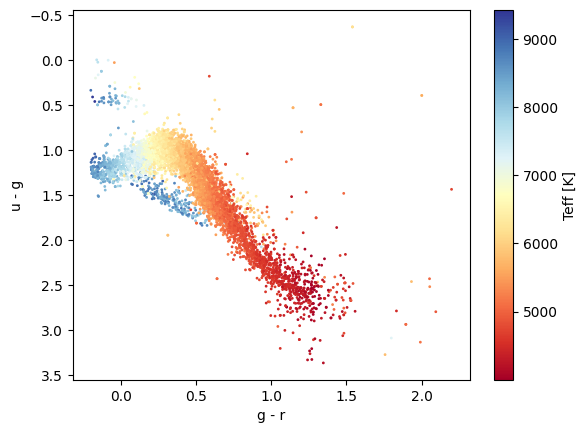

In [6]:
# Plotting the locus to see the non-linear "kinks"
plt.scatter(df_model['g_r'], df_model['u_g'], c=df_model['Teff'], cmap='RdYlBu', s=1)
plt.colorbar(label='Teff [K]')
plt.xlabel('g - r')
plt.ylabel('u - g')
plt.gca().invert_yaxis() # Traditional in astronomy
plt.show()


### Final dataset preparation

We remove:

- identifiers (objid)  
- raw magnitudes (replaced by colours)  
- individual band uncertainties (replaced by propagated noise metrics)  

This results in a clean modelling dataset containing:

- colour features  
- stellar parameters  
- global noise estimate  

The goal is to provide a compact representation suitable for statistical learning while preserving physical information.

In [7]:
cleandf = df_model.drop(columns=["objid", "u", "g", "r", "i", "z", "err_u", "err_g", "err_r","err_i", "err_z"])

cleandf.head()

,Teff,feh,logg,u_g,g_r,r_i,i_z,sigma_phot
0,5480.187,-0.490778,2.746616,1.48479,0.58193,0.21090,0.11106,0.007046
1,5166.150,-0.454237,4.488706,1.70071,0.65900,0.24273,0.13395,0.013317
2,5573.189,-0.734130,4.101281,1.25676,0.49576,0.21864,0.08085,0.034549
3,5391.255,-0.476878,4.304633,1.50259,0.63670,0.25497,0.09560,0.017776
4,5665.550,-0.445524,4.053599,1.40652,0.57958,0.21662,0.05838,0.026964


## Saving the processed dataset

We export the cleaned dataset to a CSV file for reuse in downstream notebooks.

This ensures:

- reproducibility of experiments  
- separation between data acquisition and modelling  
- efficient reuse without re-querying SDSS  

The resulting dataset is now ready for machine learning experiments on stellar parameter inference.

In [8]:
cleandf.to_csv('sdss_raw_data_v1.csv', index=False)